<a href="https://colab.research.google.com/github/SaharaAli16/UNT_Teaching/blob/main/DTSC_4050/Week_5_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Visualization

**2-hour undergraduate lecture notebook**

This notebook accompanies the Chapter 7 lecture on visualizing categorical and numerical distributions.

### Lecture flow
1. Recap: NumPy arrays
2. Importing data from files
3. Categorical distributions and bar charts
4. Numerical distributions and histograms
5. Histogram density and unequal bins
6. Overlaid graphs
7. NBA exploratory data analysis activity

The examples use **NumPy**, **Pandas**, and **Matplotlib**.


## 0. Setup

Run the setup cell first.

For the NBA examples, place **`nba_salaries.csv` in the same folder as this notebook** before running the import cells.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True


## 1. Recap: Arrays

Before working with visualization, let's revisit **arrays**, which are one of the basic structures used to store and analyze collections of values.

A NumPy array:
- stores multiple values in one object,
- supports element-by-element arithmetic,
- can be indexed to retrieve individual values,
- works naturally with functions such as `len`, `sum`, and `np.average`.

This recap follows the same ideas from the Week 3 demonstration notebook.


In [2]:
# Creating a one-dimensional NumPy array
my_array = np.array([1, 2, 3, 4])
my_array


array([1, 2, 3, 4])

### Element-wise operations


In [3]:
print("Original array:", my_array)
print("Multiply by 2:", my_array * 2)
print("Square each value:", my_array ** 2)
print("Add 1:", my_array + 1)

# The original array is unchanged unless we reassign it.
print("Still unchanged:", my_array)


Original array: [1 2 3 4]
Multiply by 2: [2 4 6 8]
Square each value: [ 1  4  9 16]
Add 1: [2 3 4 5]
Still unchanged: [1 2 3 4]


### Useful array operations


In [4]:
print("Length:", len(my_array))
print("Sum:", np.sum(my_array))
print("Mean:", np.average(my_array))


Length: 4
Sum: 10
Mean: 2.5


### Operations between arrays

Arrays with compatible shapes can be combined element by element.


In [5]:
another = np.array([70, 60, 90, 80])

print("First array: ", my_array)
print("Second array:", another)
print("Element-wise addition:", my_array + another)


First array:  [1 2 3 4]
Second array: [70 60 90 80]
Element-wise addition: [71 62 93 84]


### Indexing

Python indexing starts at **0**.


In [6]:
tunas = np.array(['bluefin', 'albacore', 'yellowfin'])

print(tunas)
print("First item:", tunas[0])
print("Third item:", tunas[2])


['bluefin' 'albacore' 'yellowfin']
First item: bluefin
Third item: yellowfin


### Columns of a DataFrame behave like arrays

A Pandas column can be converted directly to a NumPy array with `.to_numpy()`.

This is useful because:
- Pandas is convenient for labeled tabular data.
- NumPy is convenient for numerical array operations.


In [7]:
mini_nba = pd.DataFrame({
    'PLAYER': ['Player A', 'Player B', 'Player C'],
    'TEAM': ['Team 1', 'Team 1', 'Team 2'],
    'SALARY': [12.5, 8.0, 4.5]
})

salary_array = mini_nba['SALARY'].to_numpy()

print(mini_nba)
print("\nSalary as a NumPy array:", salary_array)
print("Average salary:", np.average(salary_array))


     PLAYER    TEAM  SALARY
0  Player A  Team 1    12.5
1  Player B  Team 1     8.0
2  Player C  Team 2     4.5

Salary as a NumPy array: [12.5  8.   4.5]
Average salary: 8.333333333333334


### Quick check

Suppose:

```python
scores = np.array([80, 90, 75, 95])
```

What would each expression return?

1. `scores[1]`
2. `scores + 5`
3. `np.average(scores)`


## 2. Importing Data

Real datasets are often stored outside the notebook. One common format is a **CSV (comma-separated values) file**.

There are several ways to load a CSV, depending on how we want to work with the data.

We will use `nba_salaries.csv`.


### What is Pandas?

**Pandas** is a Python library designed for working with **tabular data**.

Its main data structure is the **DataFrame**, which looks similar to a spreadsheet:
- each **column** has a name,
- each **row** represents an observation,
- columns can contain different data types,
- and we can easily filter, summarize, group, and visualize the data.

Pandas is especially useful when data comes from files such as CSV or Excel.

### 2.1 Import a CSV into a Pandas DataFrame

`pd.read_csv()` is usually the most convenient choice for tabular data because it preserves column names and supports filtering, grouping, missing-value handling, and plotting.


In [8]:
data_file = Path("nba_salaries.csv")

if not data_file.exists():
    raise FileNotFoundError(
        "Place nba_salaries.csv in the same folder as this notebook before running this cell."
    )

nba = pd.read_csv(data_file)
nba.head()


,PLAYER,POSITION,TEAM,'15-'16 SALARY
0,Paul Millsap,PF,Atlanta Hawks,18.671659
1,Al Horford,C,Atlanta Hawks,12.000000
2,Tiago Splitter,C,Atlanta Hawks,9.756250
3,Jeff Teague,PG,Atlanta Hawks,8.000000
4,Kyle Korver,SG,Atlanta Hawks,5.746479


In [9]:
print("Rows and columns:", nba.shape)
print("\nColumn names:")
print(nba.columns.tolist())

print("\nData types:")
print(nba.dtypes)


Rows and columns: (417, 4)

Column names:
['PLAYER', 'POSITION', 'TEAM', "'15-'16 SALARY"]

Data types:
PLAYER             object
POSITION           object
TEAM               object
'15-'16 SALARY    float64
dtype: object


The salary column in this dataset is named **`'15-'16 SALARY`**.  
For convenience, we will rename it to `SALARY`.


In [10]:
nba = nba.rename(columns={"'15-'16 SALARY": "SALARY"})
nba.head()


,PLAYER,POSITION,TEAM,SALARY
0,Paul Millsap,PF,Atlanta Hawks,18.671659
1,Al Horford,C,Atlanta Hawks,12.000000
2,Tiago Splitter,C,Atlanta Hawks,9.756250
3,Jeff Teague,PG,Atlanta Hawks,8.000000
4,Kyle Korver,SG,Atlanta Hawks,5.746479


### 2.2 Import CSV data directly into NumPy

NumPy can also read CSV files. This is useful when your analysis is primarily array-based.

For a file with mixed data types (text + numbers), `np.genfromtxt()` can create a **structured array**.


In [11]:
nba_numpy = np.genfromtxt(
    "nba_salaries.csv",
    delimiter=",",
    names=True,
    dtype=None,
    encoding="utf-8"
)

print("Type:", type(nba_numpy))
print("Shape:", nba_numpy.shape)
print("Field names:", nba_numpy.dtype.names)
print("\nFirst row:")
print(nba_numpy[0])


Type: <class 'numpy.ndarray'>
Shape: (417,)
Field names: ('PLAYER', 'POSITION', 'TEAM', '1516_SALARY')

First row:
('Paul Millsap', 'PF', 'Atlanta Hawks', 18.671659)


### 2.3 Import only a numerical column into a NumPy array

If we only need one numerical column, we can load that column directly.

Here, column index `3` contains salary.


In [12]:
salary_numpy = np.genfromtxt(
    "nba_salaries.csv",
    delimiter=",",
    skip_header=1,
    usecols=3
)

print("First 10 salary values:")
print(salary_numpy[:10])

print("\nAverage salary:", np.nanmean(salary_numpy))


First 10 salary values:
[18.671659 12.        9.75625   8.        5.746479  4.        3.333333
  2.        1.7634    1.30452 ]

Average salary: 5.074814482014388


### Pandas or NumPy?

| Goal | Common choice |
|---|---|
| Work with labeled rows and columns | Pandas DataFrame |
| Filter/group by team or position | Pandas DataFrame |
| Plot columns conveniently | Pandas DataFrame |
| Perform fast numerical array operations | NumPy array |
| Load only selected numerical columns | NumPy array |

In practice, data scientists frequently use **both**.


## 3. Categorical distributions

A **categorical variable** places each individual into a named group. Examples include flavor, studio, class standing, major, or survey response.

A **distribution table** shows each category and its frequency.


In [13]:
icecream = pd.DataFrame({
    'Flavor': ['Chocolate', 'Strawberry', 'Vanilla'],
    'Number of Cartons': [16, 5, 9]
})
icecream

,Flavor,Number of Cartons
0,Chocolate,16
1,Strawberry,5
2,Vanilla,9


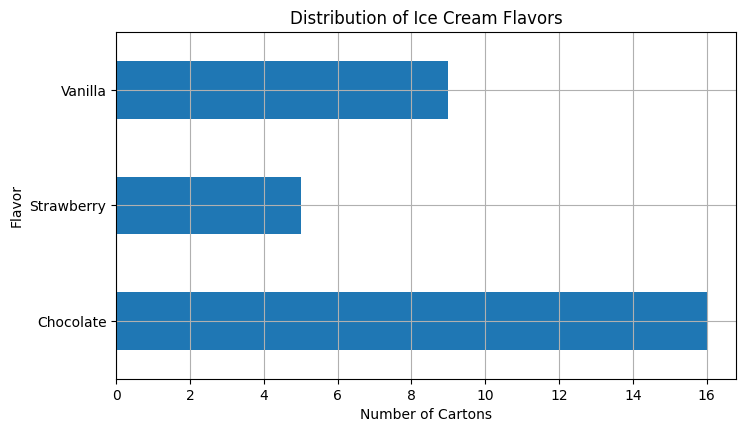

In [14]:
# Horizontal bar chart
ax = icecream.plot.barh(x='Flavor', y='Number of Cartons', legend=False)
ax.set_xlabel('Number of Cartons')
ax.set_title('Distribution of Ice Cream Flavors')
plt.show()

### Discussion:

Which flavor is most common? How quickly could you answer from the table? How quickly from the chart?


### 3.1. Sorting categories

For unordered categories, sorting bars by frequency often makes the graph easier to read.


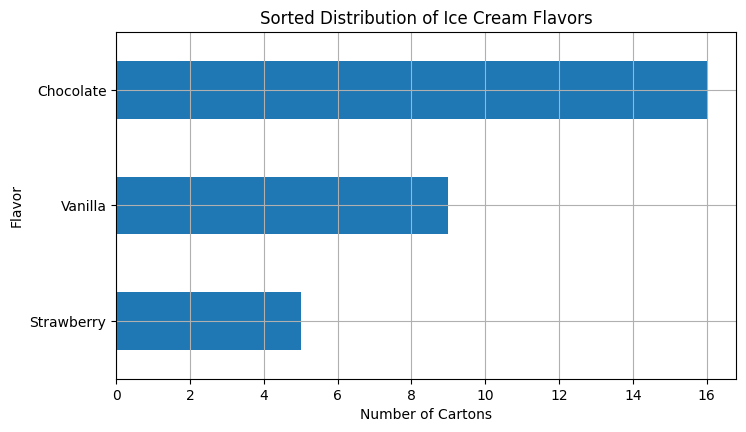

In [15]:
icecream_sorted = icecream.sort_values('Number of Cartons', ascending=True)

ax = icecream_sorted.plot.barh(x='Flavor', y='Number of Cartons', legend=False)
ax.set_xlabel('Number of Cartons')
ax.set_title('Sorted Distribution of Ice Cream Flavors')
plt.show()

### 3.2. Grouping raw categorical data

Often the data are not already counted. We first group rows by category, then plot the counts.


In [34]:
movies = pd.DataFrame({
    'Title': [
        'The Force Awakens', 'Titanic', 'Jurassic World', 'Black Panther',
        'Avengers', 'Frozen II', 'Incredibles 2', 'Toy Story 4', 'Aquaman',
        'The Lion King', 'Minions', 'Spider-Man', 'Wonder Woman', 'Finding Dory'
    ],
    'Studio': [
        'Disney', 'Paramount', 'Universal', 'Disney',
        'Disney', 'Disney', 'Disney', 'Disney', 'Warner Bros',
        'Disney', 'Universal', 'Sony', 'Warner Bros', 'Disney'
    ],
    'Adjusted Gross': [936, 659, 653, 700, 623, 477, 608, 934, 335, 543, 336, 404, 413, 486]
})
movies.head()

,Title,Studio,Adjusted Gross
0,The Force Awakens,Disney,936
1,Titanic,Paramount,659
2,Jurassic World,Universal,653
3,Black Panther,Disney,700
4,Avengers,Disney,623


In [35]:
studio_distribution = movies['Studio'].value_counts().rename_axis('Studio').reset_index(name='count')
studio_distribution

,Studio,count
0,Disney,8
1,Universal,2
2,Warner Bros,2
3,Paramount,1
4,Sony,1


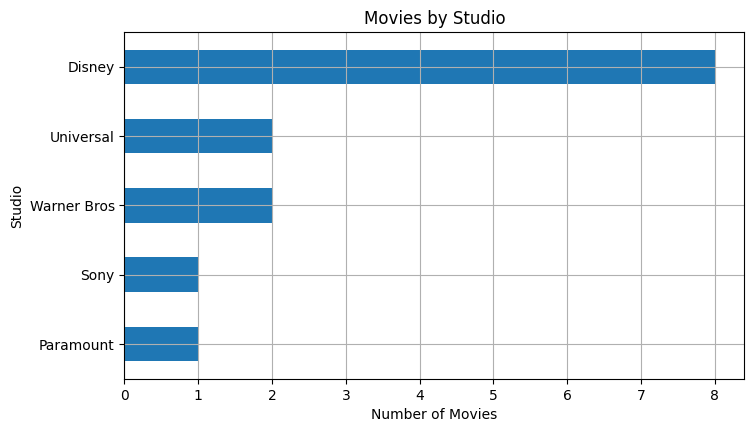

In [36]:
# Plot studios sorted by count
studio_sorted = studio_distribution.sort_values('count', ascending=True)
ax = studio_sorted.plot.barh(x='Studio', y='count', legend=False)
ax.set_xlabel('Number of Movies')
ax.set_title('Movies by Studio')
plt.show()

### 3.3. Practice:

Create a new categorical column called `Era`:

- `Classic` if Adjusted Gross is below 500
- `Blockbuster` if Adjusted Gross is 500 or above

Then create a distribution table and bar chart for `Era`.


In [37]:
# Practice 1 starter
movies['Era'] = np.where(movies['Adjusted Gross'] >= 500, 'Blockbuster', 'Classic')

era_distribution = movies['Era'].value_counts().rename_axis('Era').reset_index(name='count')
era_distribution

,Era,count
0,Blockbuster,8
1,Classic,6


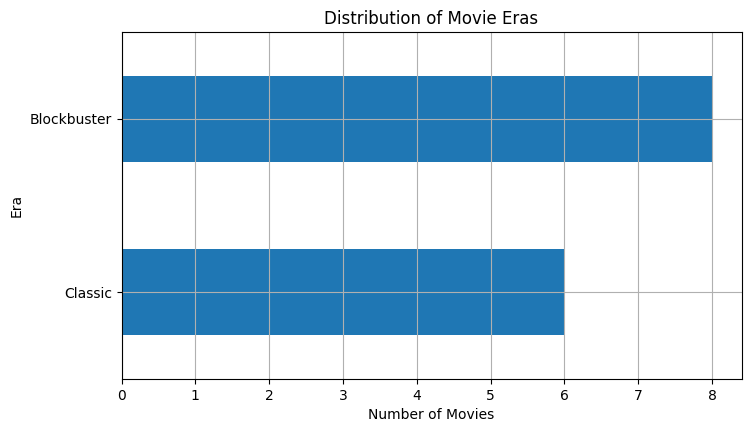

In [38]:
ax = era_distribution.sort_values('count').plot.barh(x='Era', y='count', legend=False)
ax.set_xlabel('Number of Movies')
ax.set_title('Distribution of Movie Eras')
plt.show()

## 4. Numerical distributions

A **quantitative variable** is numerical in a meaningful way. Arithmetic makes sense.

For example, adjusted gross sales can be compared, subtracted, averaged, and grouped into intervals.


In [21]:
values = movies['Adjusted Gross']
values.describe()

,Adjusted Gross
count,14.000000
mean,543.357143
std,165.737794
min,335.000000
25%,418.250000
50%,514.500000
75%,645.500000
max,936.000000


### 4.1. Binning numerical data

A **bin** is an interval such as `[300, 400)`. In most Python tools, a bin includes the left endpoint and excludes the right endpoint, except sometimes the final bin.


In [22]:
bins = np.arange(300, 1001, 100)
movies['Gross Bin'] = pd.cut(movies['Adjusted Gross'], bins=bins, right=False)
bin_counts = movies['Gross Bin'].value_counts().sort_index().reset_index()
bin_counts.columns = ['bin', 'count']
bin_counts

,bin,count
0,"[300, 400)",2
1,"[400, 500)",5
2,"[500, 600)",1
3,"[600, 700)",4
4,"[700, 800)",1
5,"[800, 900)",0
6,"[900, 1000)",1


### 4.2. Histograms

A histogram visualizes the distribution of a quantitative variable. The bars touch because bins are contiguous on the number line.


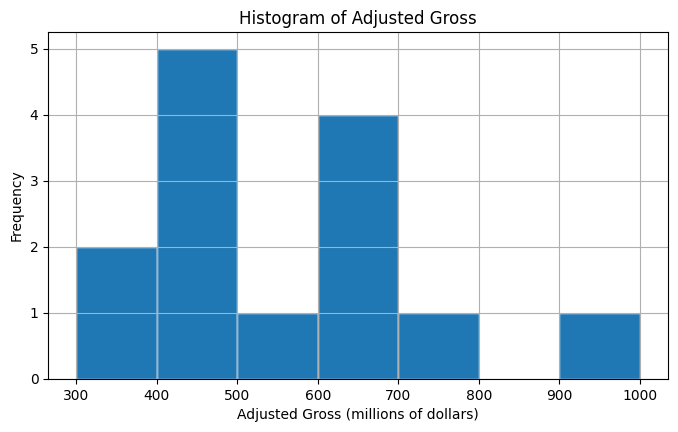

In [23]:
ax = movies['Adjusted Gross'].plot.hist(bins=bins, edgecolor='white')
ax.set_xlabel('Adjusted Gross (millions of dollars)')
ax.set_title('Histogram of Adjusted Gross')
plt.show()

### Try different bin widths

A smaller bin width gives more detail. A larger bin width gives a smoother but less detailed summary.


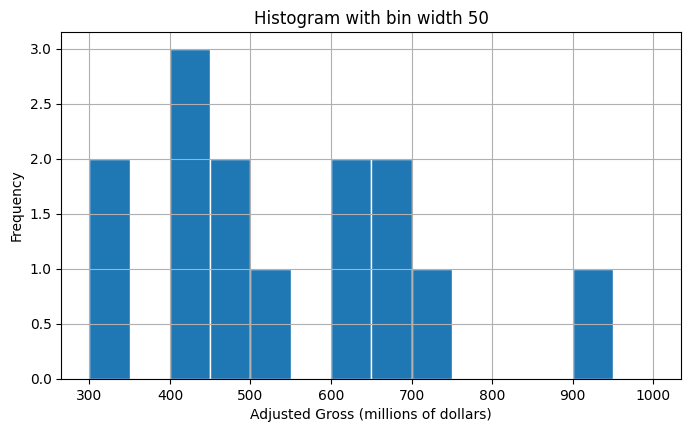

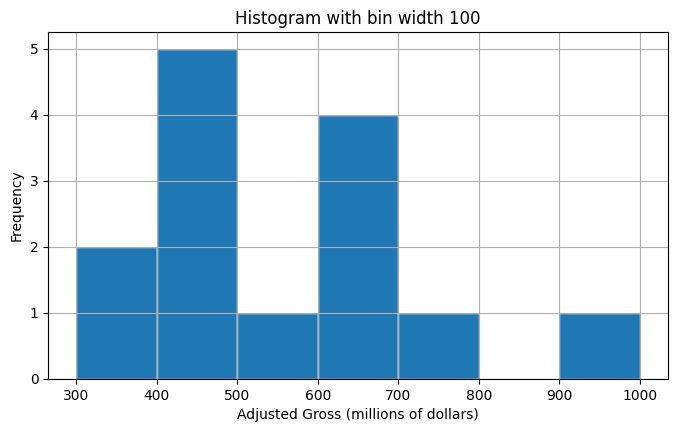

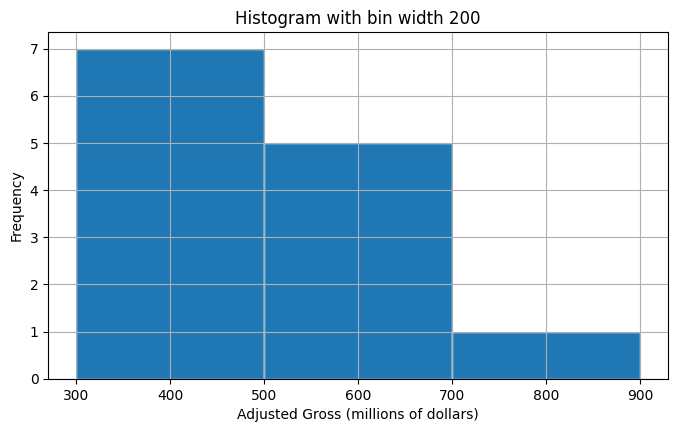

In [24]:
for width in [50, 100, 200]:
    bins_try = np.arange(300, 1001, width)
    ax = movies['Adjusted Gross'].plot.hist(bins=bins_try, edgecolor='white')
    ax.set_xlabel('Adjusted Gross (millions of dollars)')
    ax.set_title(f'Histogram with bin width {width}')
    plt.show()

### 4.3. The density scale

In Chapter 7, histograms follow the **area principle**:

This means histogram height is **density**, or crowdedness, not simply the count.


In [25]:
# Manual density calculation for equal-width bins
bin_edges = np.array([300, 400, 500, 600, 700, 1000])
counts, edges = np.histogram(movies['Adjusted Gross'], bins=bin_edges)

density_table = pd.DataFrame({
    'left_edge': edges[:-1],
    'right_edge': edges[1:],
    'width': np.diff(edges),
    'count': counts
})
density_table['percent'] = density_table['count'] / len(movies) * 100
density_table['height'] = density_table['percent'] / density_table['width']
density_table

,left_edge,right_edge,width,count,percent,height
0,300,400,100,2,14.285714,0.142857
1,400,500,100,5,35.714286,0.357143
2,500,600,100,1,7.142857,0.071429
3,600,700,100,4,28.571429,0.285714
4,700,1000,300,2,14.285714,0.047619


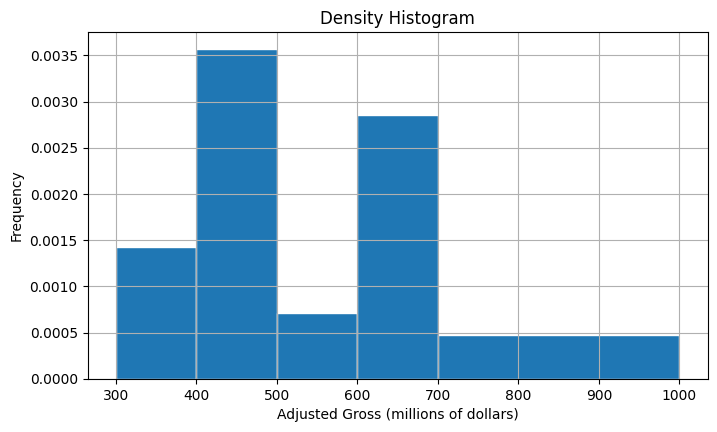

In [26]:
# Density histogram: area, not height, represents proportion
ax = movies['Adjusted Gross'].plot.hist(bins=bin_edges, density=True, edgecolor='white')
ax.set_xlabel('Adjusted Gross (millions of dollars)')
ax.set_title('Density Histogram')
plt.show()

### 4.4. Unequal bins: why counts can mislead

With unequal bins, plotting count as bar height can visually exaggerate wide bins. Density corrects this by dividing by bin width.


In [27]:
unequal_bins = np.array([300, 400, 500, 700, 1000])
counts, edges = np.histogram(movies['Adjusted Gross'], bins=unequal_bins)
unequal = pd.DataFrame({
    'left_edge': edges[:-1],
    'right_edge': edges[1:],
    'width': np.diff(edges),
    'count': counts
})
unequal['percent'] = unequal['count'] / len(movies) * 100
unequal['height'] = unequal['percent'] / unequal['width']
unequal

,left_edge,right_edge,width,count,percent,height
0,300,400,100,2,14.285714,0.142857
1,400,500,100,5,35.714286,0.357143
2,500,700,200,5,35.714286,0.178571
3,700,1000,300,2,14.285714,0.047619


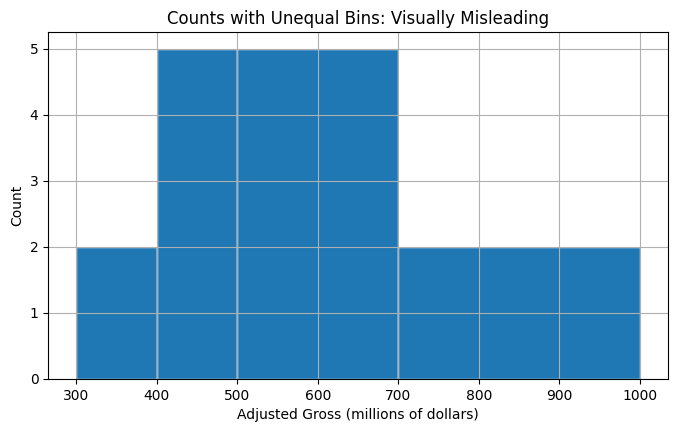

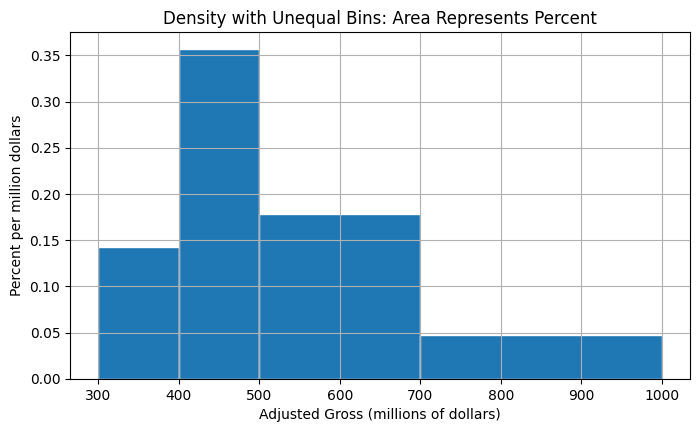

In [28]:
# Count-based display using unequal bins
plt.bar(unequal['left_edge'], unequal['count'], width=unequal['width'], align='edge', edgecolor='white')
plt.xlabel('Adjusted Gross (millions of dollars)')
plt.ylabel('Count')
plt.title('Counts with Unequal Bins: Visually Misleading')
plt.show()

# Density-based display using unequal bins
plt.bar(unequal['left_edge'], unequal['height'], width=unequal['width'], align='edge', edgecolor='white')
plt.xlabel('Adjusted Gross (millions of dollars)')
plt.ylabel('Percent per million dollars')
plt.title('Density with Unequal Bins: Area Represents Percent')
plt.show()

### 4.5. Practice 2

For the bin `[500, 700)`, compute the count, percent, width, and height manually. Then confirm your answer from the `unequal` table.


In [29]:
# Practice 2 starter
selected = unequal[(unequal['left_edge'] == 500) & (unequal['right_edge'] == 700)]
selected

,left_edge,right_edge,width,count,percent,height
2,500,700,200,5,35.714286,0.178571


## 5. Bar chart versus histogram

| Feature | Bar chart | Histogram |
|---|---|---|
| Variable type | Categorical | Quantitative |
| Bar order | Can often be rearranged | Fixed by number line |
| Bar spacing | Bars have gaps | Bars touch |
| Bar width | Design choice | Bin width |
| Height means | Count or percent | Density |
| Area means | Not the main encoding | Percent or proportion in bin |


## 6. Overlaid graphs

Overlaid graphs are useful for comparing datasets, but only when they share common axes and units.


### 6.1 Overlaid scatter plots

We compare two relationships with one common x-axis.


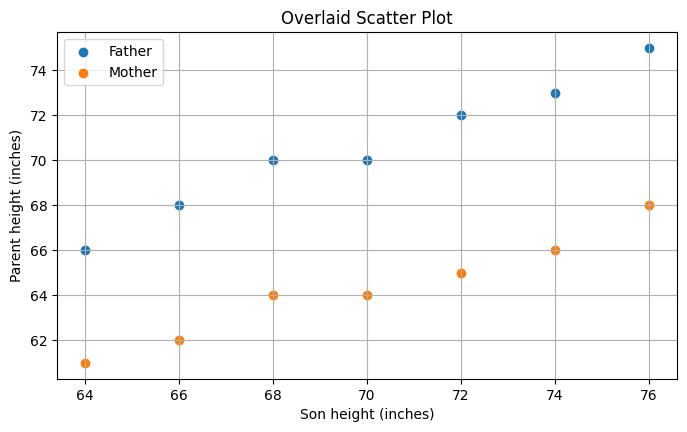

In [30]:
heights = pd.DataFrame({
    'son': [64, 66, 68, 70, 72, 74, 76],
    'father': [66, 68, 70, 70, 72, 73, 75],
    'mother': [61, 62, 64, 64, 65, 66, 68]
})

plt.scatter(heights['son'], heights['father'], label='Father')
plt.scatter(heights['son'], heights['mother'], label='Mother')
plt.xlabel('Son height (inches)')
plt.ylabel('Parent height (inches)')
plt.title('Overlaid Scatter Plot')
plt.legend()
plt.show()

### 6.2 Overlaid line plots

Line plots are useful when the x-axis has a meaningful order, such as age or time.


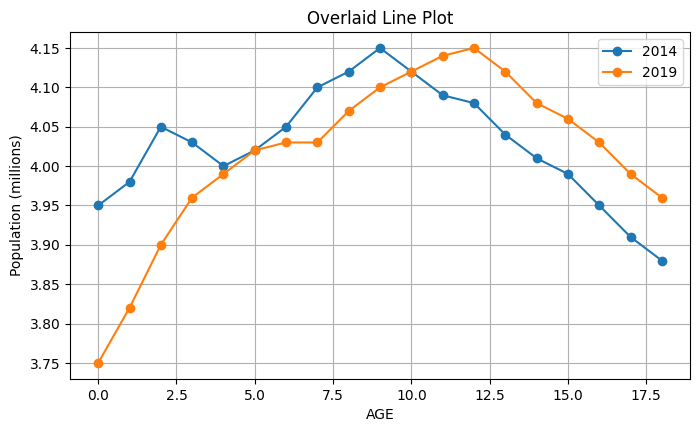

In [31]:
age = np.arange(19)
children = pd.DataFrame({
    'AGE': age,
    '2014': [3.95, 3.98, 4.05, 4.03, 4.00, 4.02, 4.05, 4.10, 4.12, 4.15, 4.12, 4.09, 4.08, 4.04, 4.01, 3.99, 3.95, 3.91, 3.88],
    '2019': [3.75, 3.82, 3.90, 3.96, 3.99, 4.02, 4.03, 4.03, 4.07, 4.10, 4.12, 4.14, 4.15, 4.12, 4.08, 4.06, 4.03, 3.99, 3.96]
})

ax = children.plot(x='AGE', y=['2014', '2019'], marker='o')
ax.set_ylabel('Population (millions)')
ax.set_title('Overlaid Line Plot')
plt.show()

### 6.3 Overlaid bar charts

Overlaid bar charts can compare categorical distributions across groups. They are easiest to interpret when comparing one pair at a time.


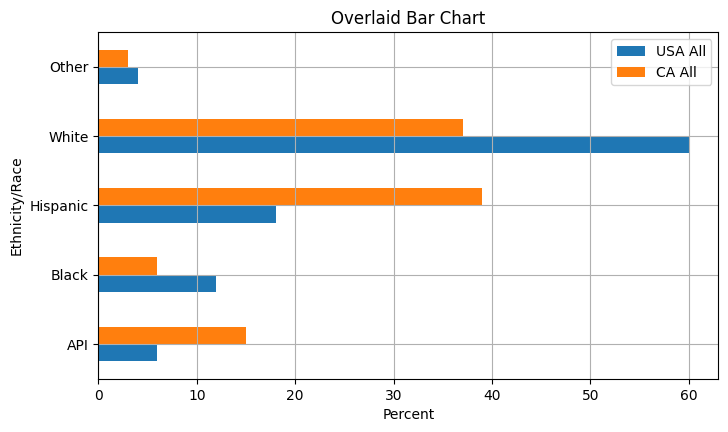

In [32]:
race = pd.DataFrame({
    'Ethnicity/Race': ['API', 'Black', 'Hispanic', 'White', 'Other'],
    'USA All': [6, 12, 18, 60, 4],
    'CA All': [15, 6, 39, 37, 3]
})

ax = race.plot.barh(x='Ethnicity/Race', y=['USA All', 'CA All'])
ax.set_xlabel('Percent')
ax.set_title('Overlaid Bar Chart')
plt.show()